In [1]:
!pip install -Uqq fastai
!pip install -Uqq fastbook

In [2]:
from fastai.vision.all import *
from fastbook import *

matplotlib.rc('image', cmap='Greys')

In [3]:
# path = untar_data(URLs.MNIST_SAMPLE)
# Path("/ai/").ls()
path = untar_data(URLs.MNIST_SAMPLE)

In [4]:
path.ls()

(#3) [Path('/root/.fastai/data/mnist_sample/labels.csv'),Path('/root/.fastai/data/mnist_sample/valid'),Path('/root/.fastai/data/mnist_sample/train')]

In [5]:
threes = (path/"train"/"3").ls().sorted()
sevens = (path/"train"/"7").ls().sorted()
threes

(#6131) [Path('/root/.fastai/data/mnist_sample/train/3/10.png'),Path('/root/.fastai/data/mnist_sample/train/3/10000.png'),Path('/root/.fastai/data/mnist_sample/train/3/10011.png'),Path('/root/.fastai/data/mnist_sample/train/3/10031.png'),Path('/root/.fastai/data/mnist_sample/train/3/10034.png'),Path('/root/.fastai/data/mnist_sample/train/3/10042.png'),Path('/root/.fastai/data/mnist_sample/train/3/10052.png'),Path('/root/.fastai/data/mnist_sample/train/3/1007.png'),Path('/root/.fastai/data/mnist_sample/train/3/10074.png'),Path('/root/.fastai/data/mnist_sample/train/3/10091.png')...]

In [6]:
im3_path = threes[1]
im3 = Image.open(im3_path)
im3

In [7]:
array(im3)[4:10, 4:10]

array([[  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  29],
       [  0,   0,   0,  48, 166, 224],
       [  0,  93, 244, 249, 253, 187],
       [  0, 107, 253, 253, 230,  48],
       [  0,   3,  20,  20,  15,   0]], dtype=uint8)

In [8]:
tensor(im3)[4:10, 4:10]

tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,  29],
        [  0,   0,   0,  48, 166, 224],
        [  0,  93, 244, 249, 253, 187],
        [  0, 107, 253, 253, 230,  48],
        [  0,   3,  20,  20,  15,   0]], dtype=torch.uint8)

In [9]:
tensor(im3).shape

torch.Size([28, 28])

In [10]:
im3_t = tensor(im3)
df = pd.DataFrame(im3_t[4:15, 4:32])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Blues')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0,0,0,0,0,0,0
2,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0,0,0,0,0,0,0
3,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0,0,0,0,0,0,0
4,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0,0,0,0,0,0,0
5,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,249,253,245,126,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,14,101,223,253,248,124,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,11,166,239,253,253,253,187,30,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,16,248,250,253,253,253,253,232,213,111,2,0,0,0,0,0,0,0,0


In [11]:
seven_tensors = [tensor(Image.open(o)) for o in sevens]
three_tensors = [tensor(Image.open(o)) for o in threes]
len(seven_tensors), len(three_tensors)

(6265, 6131)

<Axes: >

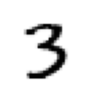

In [12]:
show_image(three_tensors[1])

In [13]:
stacked_sevens = torch.stack(seven_tensors).float()/255
stacked_threes = torch.stack(three_tensors).float()/255
stacked_threes.shape,stacked_sevens.shape

(torch.Size([6131, 28, 28]), torch.Size([6265, 28, 28]))

<Axes: >

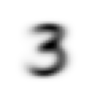

In [14]:
mean3 = stacked_threes.mean(0)
show_image(mean3)
# mean3.shape

<Axes: >

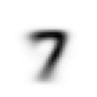

In [15]:
mean7 = stacked_sevens.mean(0)
show_image(mean7)

<Axes: >

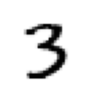

In [16]:
a_3 = stacked_threes[1]
show_image(a_3)

In [17]:
dist_3_abs = (a_3 - mean3).abs().mean()
dist_3_sqr = ((a_3 - mean3)**2).mean()
dist_3_abs, dist_3_sqr

(tensor(0.1114), tensor(0.0408))

In [18]:
a_7 = stacked_sevens[1]
dist_7_abs = (a_3 - mean7).abs().mean()
dist_7_sqr = ((a_3 - mean7)**2).abs().mean()
dist_7_abs, dist_7_sqr

(tensor(0.1586), tensor(0.0913))

In [20]:
F.l1_loss(a_3, mean7), F.mse_loss(a_3, mean7)

(tensor(0.1586), tensor(0.0913))

In [21]:
data = [[1,2,3],[4,5,6]]
arr = array(data)
tns = tensor(data)

In [22]:
arr

array([[1, 2, 3],
       [4, 5, 6]])

In [23]:
tns

tensor([[1, 2, 3],
        [4, 5, 6]])

In [24]:
# Image.open((path/"valid"/"3").ls()[0])
valid3_tens = torch.stack([tensor(Image.open(o)) for o in (path/"valid"/"3").ls()]).float()/255
# valid3_tens
valid7_tens = torch.stack([tensor(Image.open(o)) for o in (path/"valid"/"7").ls()]).float()/255

valid3_tens.shape, valid7_tens.shape

(torch.Size([1010, 28, 28]), torch.Size([1028, 28, 28]))

In [25]:
def mnist_distance(a,b): return (a-b).abs().mean((-1,-2))
mnist_distance(a_3, mean3)
# (a_3-mean3).abs().mean(), (a_3-mean3).abs().mean((-1,-2)), (a_3-mean3).abs().mean((0,1))


tensor(0.1114)

In [26]:
valid3_dist = mnist_distance(valid3_tens, mean3)
valid3_dist, valid3_dist.shape

(tensor([0.1369, 0.1380, 0.1258,  ..., 0.1167, 0.1221, 0.1206]),
 torch.Size([1010]))

In [27]:
def is_3(x): return mnist_distance(x,mean3) < mnist_distance(x, mean7)

In [28]:
is_3(a_3), is_3(a_3).float()

(tensor(True), tensor(1.))

In [29]:
is_3(valid3_tens)

tensor([ True,  True,  True,  ...,  True,  True, False])

In [31]:
accuracy_3s = is_3(valid3_tens).float().mean()
accuracy_7s = (1 - is_3(valid7_tens).float()).mean()
accuracy_3s, accuracy_7s

(tensor(0.9168), tensor(0.9854))

In [32]:
def f(x): return x**2

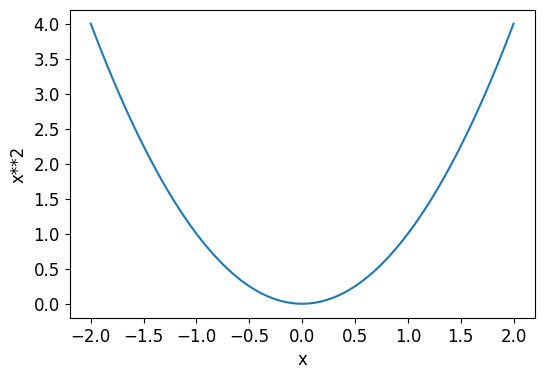

In [33]:
plot_function(f, "x", "x**2")

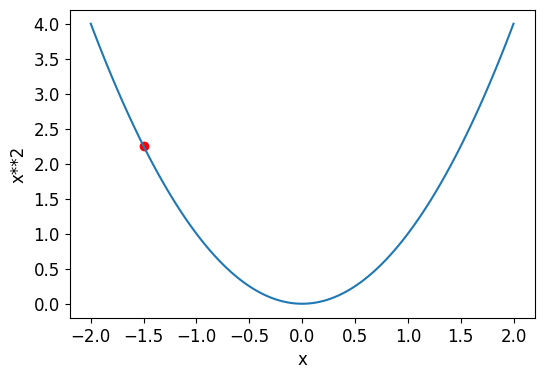

In [35]:
plot_function(f, "x", "x**2")
plt.scatter(-1.5, f(-1.5), color="red")

In [40]:
xt1 = tensor(3.).requires_grad_()

In [41]:
yt = f(xt1)
yt.grad_fn

In [42]:
yt.backward()

In [43]:
xt1.grad

tensor(6.)

In [45]:
xt = tensor([3.,4.,10.]).requires_grad_()
xt

tensor([ 3.,  4., 10.], requires_grad=True)

In [46]:
def f(x): return (x**2).sum()

yt = f(xt)
yt

tensor(125., grad_fn=<SumBackward0>)

In [47]:
yt.backward()
xt.grad

tensor([ 6.,  8., 20.])

In [48]:
time = torch.arange(0,20).float(); time

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19.])

In [54]:
speed = torch.randn(20) * 3 + 0.75 * (time-9.5)**2 + 1
speed

tensor([70.8660, 55.4610, 42.0203, 34.2712, 22.6048, 16.0057, 10.4073,  8.1435,  7.1289,  2.2223, -3.0849,  2.3385,  6.3402, 10.0475, 11.8869, 21.9879, 31.4116, 43.9751, 50.8701, 70.2516])

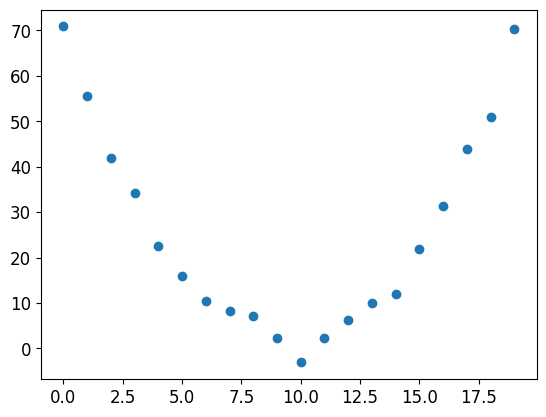

In [55]:
plt.scatter(time, speed)

In [56]:
def f(t, params):
    a,b,c = params
    return a*(t**2)+b*t+c

In [57]:
def mse(preds, targets): return ((preds - targets)**2).mean()

In [58]:
params = torch.randn(3).requires_grad_()

In [59]:
orig_params = params.clone()

In [60]:
preds = f(time, params)

In [62]:
def show_preds(preds, ax=None):
    if ax is None: ax=plt.subplots()[1]
    ax.scatter(time, speed)
    ax.scatter(time, to_np(preds), color='red')
    ax.set_ylim(-300,100)

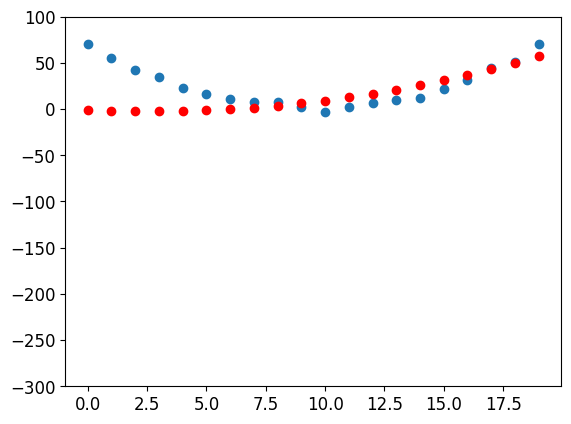

In [73]:
show_preds(preds)

In [74]:
loss = mse(preds, speed)
loss

tensor(687.4767, grad_fn=<MeanBackward0>)

In [75]:
loss.backward()
params.grad

tensor([509.9192,  11.9932, -20.9726])

In [76]:
params.grad * 1e-5

tensor([ 0.0051,  0.0001, -0.0002])

In [77]:
params

tensor([ 0.2303, -1.3297, -0.5426], requires_grad=True)

In [78]:
lr = 1e-5
params.data -= lr * params.grad.data
params.grad = None

In [79]:
preds = f(time, params)
mse(preds, speed)

tensor(685.6041, grad_fn=<MeanBackward0>)

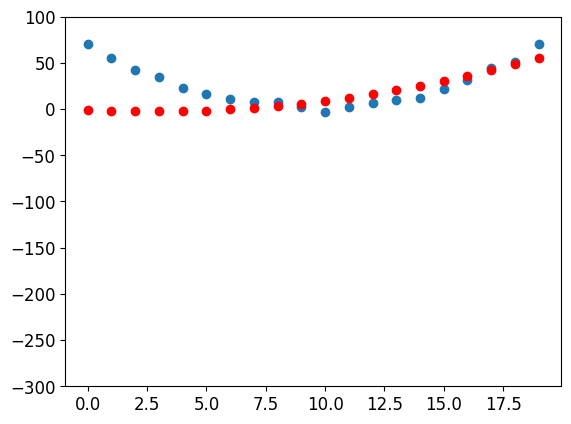

In [80]:
show_preds(preds)